In [1]:
import sys
from pathlib import Path

# Ensure repo root is on sys.path so 'src' is importable
repo_root = str(Path.cwd().parents[1]) if Path.cwd().name == 'research_questions' else str(Path.cwd())
if repo_root not in sys.path:
    sys.path.insert(0, repo_root)

In [2]:
from src.analysis.get_results import get_pandas_dataset
from src.analysis.dataset_graphs import plot_graphs_of_dataset_loc
from src.analysis.get_tables_results import create_table_cleaned
from src.analysis.get_results import bar_chart_fix_position_cleaned
from src.analysis.get_results import sucess_vs_position_cleaned,get_latex_table_with_verif_stats
from src.analysis.get_results import compute_stats_tests

import src.config as gl
import pandas as pd

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.width', None)

In [3]:
RESULT_DIR = gl.BASE_PATH / "results/dafny_llm_results_rq1__best_overall"
DATASET_DIR = gl.DAFNY_ASSERTION_DATASET
print(DATASET_DIR)
print(RESULT_DIR)
verif_data_pd = get_pandas_dataset(DATASET_DIR, RESULT_DIR)
verif_data_pd  = verif_data_pd.assign(success=lambda d: d['verif_sucess'] > 0) 

/app/dataset/dafny_assertion_dataset
/app/results/dafny_llm_results_rq1__best_overall



\begin{table}[!t]
\begin{center}
\small
\caption{Verification success rate of each approach across benchmark categories, using the best retrieval strategy MulEmb$0.25_{in}$.}
\label{tbl:assertion-inference-verification}
\begin{tabular}{|l|c|c|c|c|}
\hline
\multirow{2}{*}{Approach} & \multicolumn{4}{c|}{Benchmarks} \\
\cline{2-5}
 & w/o-1 (236) & w/o-2 (184) & All (28) & Combined (448) \\
\hline
DiagFL & 124 (52.5\%) & \phantom{0}12 (\phantom{0}6.5\%) & \phantom{00}3 (10.7\%) & 139 (31.0\%) \\
LLMFL$ & 116 (49.2\%) & \phantom{0}18 (\phantom{0}9.8\%) & \phantom{00}6 (21.4\%) & 140 (31.2\%) \\
DiagFL+ & 136 (57.6\%) & \phantom{00}6 (\phantom{0}3.3\%) & \phantom{00}3 (10.7\%) & 145 (32.4\%) \\
ExLLMFL & 126 (53.4\%) & \phantom{0}18 (\phantom{0}9.8\%) & \phantom{00}5 (17.9\%) & 149 (33.3\%) \\
BothFL & 159 (67.4\%) & \phantom{0}26 (14.1\%) & \phantom{00}6 (21.4\%) & 191 (42.6\%) \\
ExactFL & 169 (71.6\%) & \phantom{0}48 (26.1\%) & \phantom{00}7 (25.0\%) & 224 (50.0\%) \\
OPUS DiagFL+ & 178

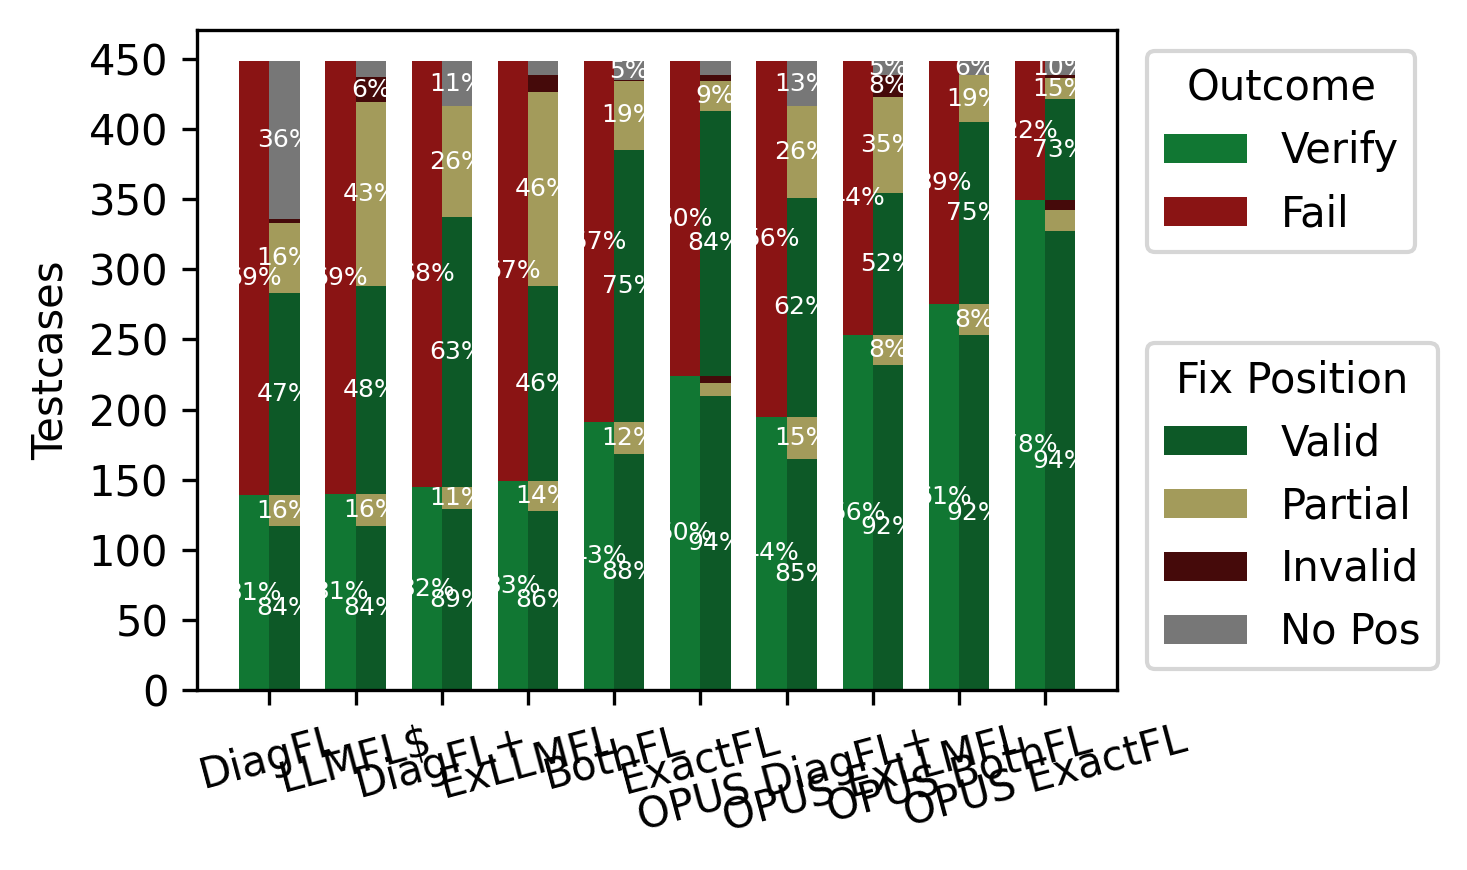

In [4]:
# Graphs of position evaluation
test_models = {
    "claude-haiku-4.5__loc_LAUREL_inf_LLM_EXAMPLE_sExInf_DYNAMIC_nExInf_3_aExInf_0.25": "DiagFL",
    "claude-haiku-4.5__loc_LLM_inf_LLM_EXAMPLE_sExInf_DYNAMIC_nExInf_3_aExInf_0.25": "LLMFL$",
    "claude-haiku-4.5__loc_LAUREL_BETTER_inf_LLM_EXAMPLE_sExInf_DYNAMIC_nExInf_3_aExInf_0.25": "DiagFL+",
    "claude-haiku-4.5__loc_LLM_EXAMPLE_inf_LLM_EXAMPLE_sExPos_DYNAMIC_nExPos_3_aExPos_0.25_sExInf_DYNAMIC_nExInf_3_aExInf_0.25": "ExLLMFL",
    "claude-haiku-4.5__loc_HYBRID_inf_LLM_EXAMPLE_sExPos_DYNAMIC_nExPos_3_aExPos_0.25_sExInf_DYNAMIC_nExInf_3_aExInf_0.25": "BothFL",
    "claude-haiku-4.5__loc_ORACLE_inf_LLM_EXAMPLE_sExInf_DYNAMIC_nExInf_3_aExInf_0.25": "ExactFL",

    "claude-opus-4.5__loc_LAUREL_BETTER_inf_LLM_EXAMPLE_sExInf_DYNAMIC_nExInf_3_aExInf_0.25": "OPUS DiagFL+",
    "claude-opus-4.5__loc_LLM_EXAMPLE_inf_LLM_EXAMPLE_sExPos_DYNAMIC_nExPos_3_aExPos_0.25_sExInf_DYNAMIC_nExInf_3_aExInf_0.25": "OPUS ExLLMFL",
    "claude-opus-4.5__loc_HYBRID_inf_LLM_EXAMPLE_sExPos_DYNAMIC_nExPos_3_aExPos_0.25_sExInf_DYNAMIC_nExInf_3_aExInf_0.25": "OPUS BothFL",
    "claude-opus-4.5__loc_ORACLE_inf_LLM_EXAMPLE_sExInf_DYNAMIC_nExInf_3_aExInf_0.25": "OPUS ExactFL"
}

#verif_data_pd = verif_data_pd[verif_data_pd["benchmark"] == "w/o-1"]
#verif_data_pd = verif_data_pd[verif_data_pd["benchmark"] != "w/o-1"]

dual_name = "rq1__best_overall.pdf"
images_p = gl.BASE_PATH / "images"
info = get_latex_table_with_verif_stats(verif_data_pd, "Verification success rate of each approach across benchmark categories, using the best retrieval strategy MulEmb$0.25_{in}$.", "tbl:assertion-inference-verification", test_models)
print(info)
sucess_vs_position_cleaned(verif_data_pd ,"DOUBLE",   test_models, images_p / dual_name)

In [5]:
verif_renamed = verif_data_pd.copy()
verif_renamed["llm"] = verif_renamed["llm"].map(test_models)

# OPUS
print("##### Comparing OPUS DiagFL+ with OPUS ExLLMFL #####")
compute_stats_tests("OPUS DiagFL+","OPUS ExLLMFL", verif_renamed)

print("##### Comparing OPUS DiagFL+ with OPUS BothFL #####")
compute_stats_tests("OPUS DiagFL+","OPUS BothFL", verif_renamed)

print("##### Comparing OPUS BothFL with OPUS ExLLMFL #####")
compute_stats_tests("OPUS BothFL","OPUS ExLLMFL", verif_renamed)

# HAIKU
print("##### Comparing DiagFL+ with ExLLMFL #####")
compute_stats_tests("DiagFL+","ExLLMFL", verif_renamed)

print("##### Comparing DiagFL+ with BothFL #####")
compute_stats_tests("DiagFL+","BothFL", verif_renamed)

print("##### Comparing BothFL with ExLLMFL #####")
compute_stats_tests("BothFL","ExLLMFL", verif_renamed)

##### Comparing OPUS DiagFL+ with OPUS ExLLMFL #####

--- McNemar Matrix [[d,c],[b,a]]: ---
[[168, 85], [27, 168]]

--- Results McNemar (is one better than the other) ---
pvalue      3.5803042787073536e-08
statistic   27.0
Agreements (d): OPUS DiagFL+ Failures, OPUS ExLLMFL Failure: 168
Agreements (a): OPUS DiagFL+ Success, OPUS ExLLMFL Success: 168
Disagreements (b): OPUS DiagFL+ Success, OPUS ExLLMFL Failure: 27
Disagreements (c): OPUS DiagFL+ Failure, OPUS ExLLMFL Success: 85
P-Value: 3.5803042787073536e-08
!!! Models are statistically different (one is better than the other) !!!

--- Results Chi-squared Test of Independence are they independent ---
--- Chi-Squared Matrix [[d,c],[b,a]]: ---
[[168, 85], [27, 168]]
--- Chi-Squared Test Results ---
Chi-Squared Statistic: 121.6194
P-Value: 0.0000
Degrees of Freedom: 1
Expected Frequencies (if independent):
[[110.12 142.88]
 [ 84.88 110.12]]
!!! Models are not independent !!!
Effect Sizes
Phi (φ) Coefficient: 0.521
Jaccard Index (Overlap